# Population inversion in a three-level atom

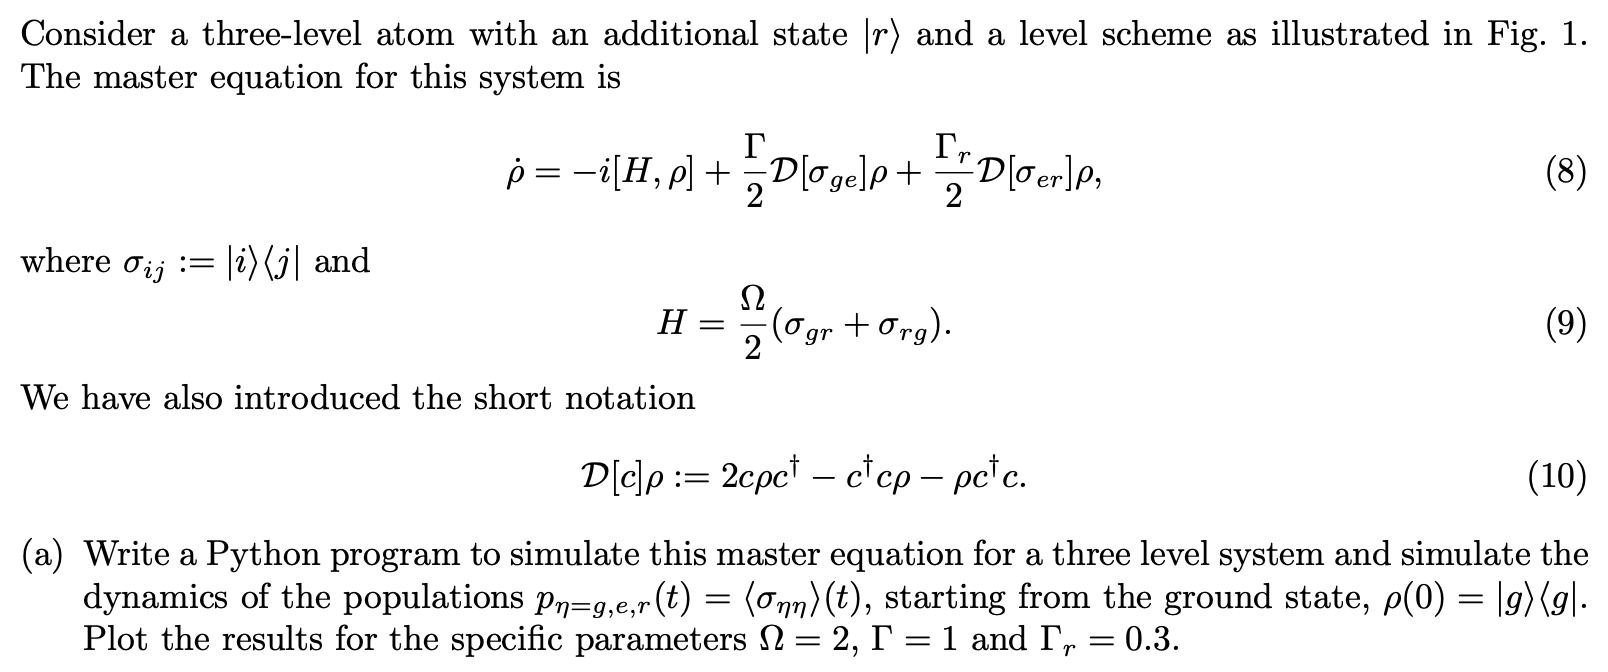
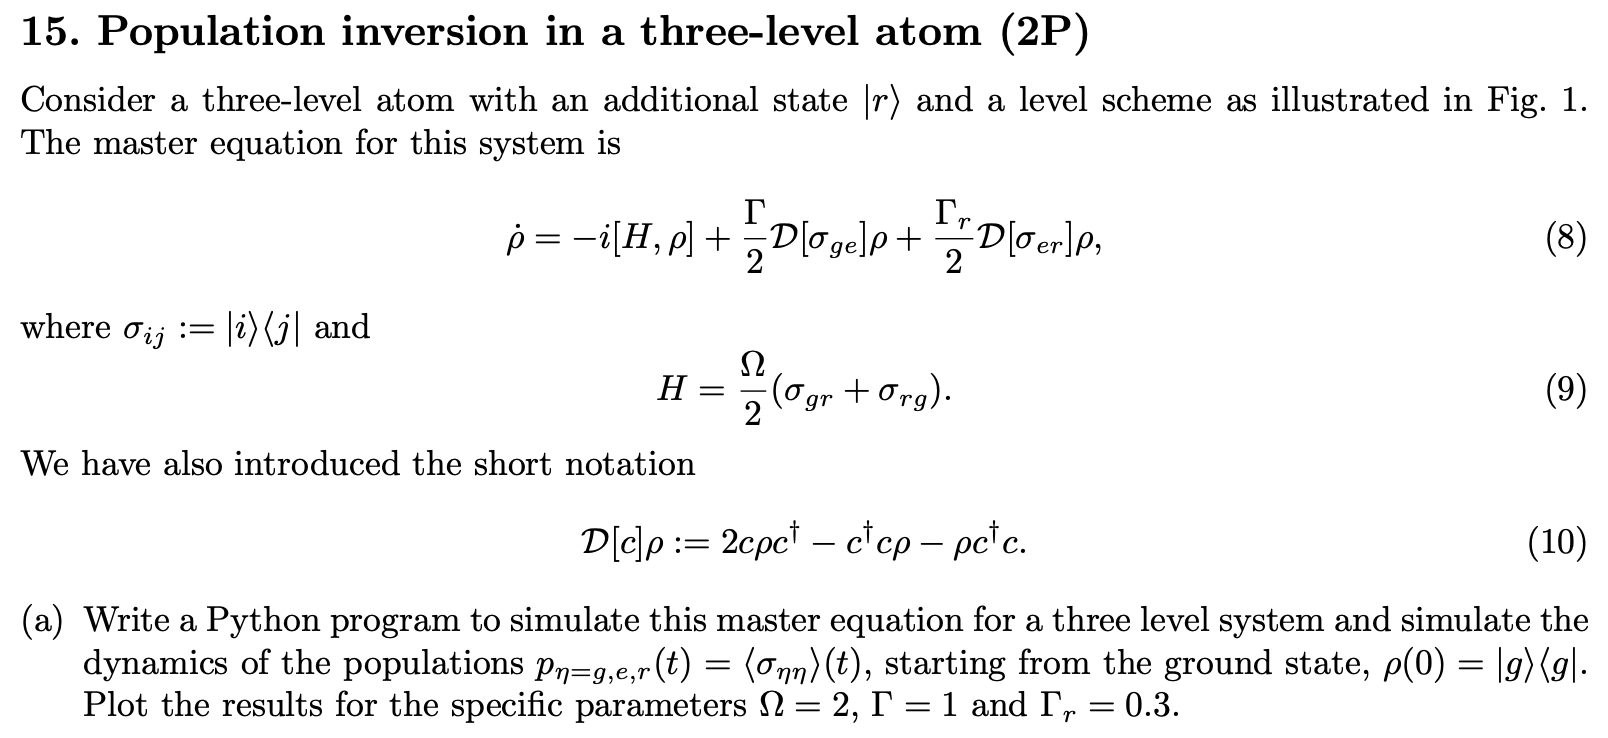

## Scheme:

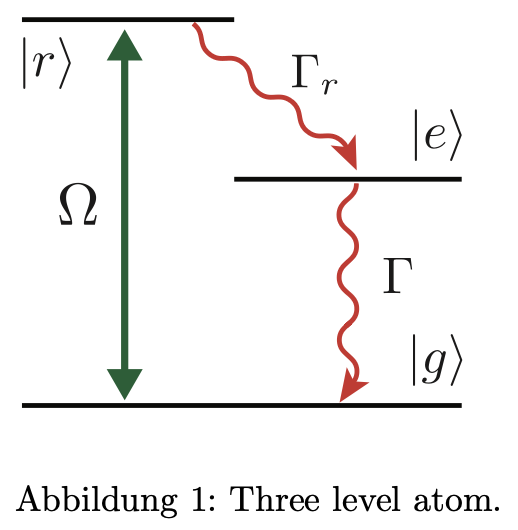

## Setup

In [1]:
#importing modules and functions

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time

from qutip import Qobj   # use Qobj(A) to generate a better readable output of a matrix or vector A

np.set_printoptions(precision=3)

#nicer latex fonts in plots:
# increase the font size
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 12,
}) 

## Operators

In [2]:
def matrix_withone(dim, i, j):
    """
    Returns a matrix of size dim x dim with a 1 at position (i,j) and 0 elsewhere.
    """
    A = np.zeros((dim, dim), dtype = complex)
    A[i, j] = 1
    return A

s_gr = matrix_withone(3, 0, 2)
s_rg = s_gr.T
s_ge = matrix_withone(3, 0, 1)
s_eg = s_ge.T
s_er = matrix_withone(3, 1, 2)
s_re = s_er.T
s_gg = matrix_withone(3, 0, 0)
s_rr = matrix_withone(3, 2, 2)
s_ee = matrix_withone(3, 1, 1)

def H0(Omega):
    """
    Returns the Hamiltonian for the system with Rabi frequency Omega.
    """
    return Omega / 2 * (s_gr + s_rg)

## Time evolution code

In [3]:
def build_Liouvillian_t_indep(H0:np.ndarray, jump_ops:list = []) -> np.ndarray:
    """
    Builds the Liouvillian superoperator for the system.

    Parameters:
    - H0: Hamiltonian (as a 2D numpy array)
    - Hdrives: list of drive Hamiltonians (each as a tuple of (operator, drive_function))
    - jump_ops: list of jump operators (each as a tuple of (operator, rate))

    Returns:
    - L: Liouvillian superoperator (as a 2D numpy array)
    """
    # dimension of the system
    dim = H0.shape[0]
    identity = np.eye(dim)
    # Build total Hamiltonian at time t
    H = H0.copy()
    # build the Hamiltonian part of the Liouvillian
    L_hamiltonian = -1j * (np.kron(H, identity) - np.kron(identity, H.T))

    # build jump parts of the master equation
    jump_parts = []
    for op, rate in jump_ops:
        D = 2 * np.kron(op, op.conj()) - np.kron(op.conj().T @ op, identity) - np.kron(identity, (op.conj().T @ op).T)
        jump_parts.append(D * rate / 2)

    # Combine all parts to form the Liouvillian superoperator
    L = L_hamiltonian + sum(jump_parts)

    return L

def rhodot(t, rho:np.ndarray, H0:np.ndarray, Hdrives:list = [], jump_ops:list = []) -> np.ndarray:
    """
    Computes the time derivative of the density matrix rho at time t.
    
    Parameters:
    - t: time
    - rho: density matrix (as a 1D numpy array)
    - H0: Hamiltonian (as a 2D numpy array)
    - Hdrives: list of drive Hamiltonians (each as a tuple of (operator, drive_function))
    - jump_ops: list of jump operators (each as a tuple of (operator, rate))
    
    Returns:
    - drho: time derivative of the density matrix (as a 1D numpy array)
    """
    # dimension of the system
    dim = H0.shape[0]
    identity = np.eye(dim)
    # Build total Hamiltonian at time t
    H = H0.copy()
    for op, drive in Hdrives:
        H += op * drive(t)
    # build the Hamiltonian part of the Liouvillian
    L_hamiltonian = -1j * (np.kron(H, identity) - np.kron(identity, H.T))
    
    # build jump parts of the master equation
    jump_parts = []
    for op, rate in jump_ops:
        D = 2 * np.kron(op, op.conj()) - np.kron(op.conj().T @ op, identity) - np.kron(identity, (op.conj().T @ op).T)
        jump_parts.append(D * rate / 2)

    # Combine all parts to form the Liouvillian superoperator
    L = L_hamiltonian + sum(jump_parts)

    # Apply the Liouvillian to the density matrix (as a 1d numpy array)
    return L @ rho


## Parameters and initial state

In [4]:
Omega = 2.0
Gamma = 1.0
Gamma_r = 0.3

rho_0 = np.zeros((3, 3), dtype=np.complex128)  # initial density matrix
rho_0[0, 0] = 1.0  # initial state is |g>
rho_0 = rho_0.flatten()  # flatten to 1D array for the solver
H0_matrix = H0(Omega)

## Simulation

In [5]:
# define jump operators and rates
jump_ops = [
    (s_ge, Gamma),  # spontaneous emission from excited state to ground state
    (s_er, Gamma_r)  # spontaneous emission from excited state to reservoir
]
# run the solver
t_list = np.linspace(0, 10 * np.pi, 1000)  # time points to evaluate

sol = solve_ivp(
    rhodot,
    [t_list[0], t_list[-1]],
    rho_0,
    t_eval=t_list,
    args=(H0_matrix, [], jump_ops),
    method='RK45'
)

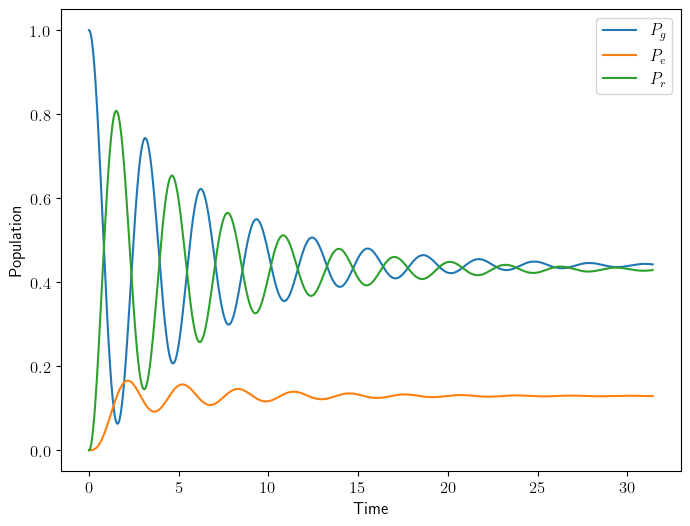

In [6]:
sol_rho = sol.y.T  # transpose to get shape (time, dim^2)
sol_t = sol.t
# calculate populations
pg = np.real(sol_rho[:, 0])  # population of |g>
pe = np.real(sol_rho[:, 4])  # population of |e>
pr = np.real(sol_rho[:, 8])  # population of |r>

# plot the populations
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sol_t, pg, label=r'$P_g$')
ax.plot(sol_t, pe, label=r'$P_e$')
ax.plot(sol_t, pr, label=r'$P_r$')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()

## b)
 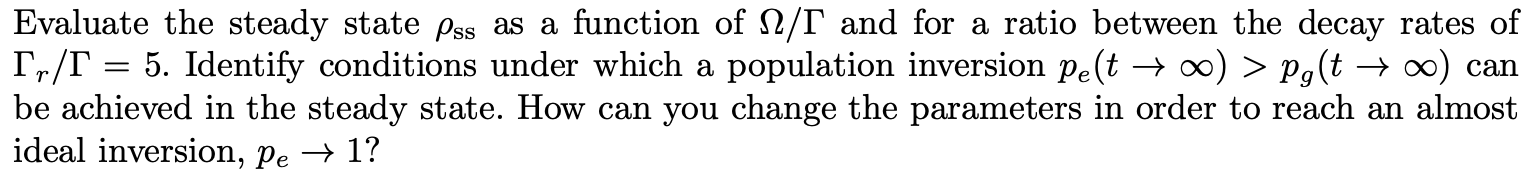

In [7]:
def steady_state(L:np.ndarray) -> np.ndarray:
    """
    Computes the steady state of the system described by the Liouvillian superoperator L.
    It does this by finding the eigenvector in the kernel of L.

    Parameters:
    - L: Liouvillian superoperator (as a 2D numpy array)
    Returns:
    - rho_ss: steady state density matrix (as a 1D numpy array)
    """
    # Find the eigenvalues and eigenvectors of L
    eigenvalues, eigenvectors = np.linalg.eig(L)
    
    # Find the index of the zero eigenvalue (steady state)
    index = np.isclose(eigenvalues, 0, atol=1e-10)
    
    if np.sum(index) == 0:
        raise ValueError("No steady state found (no zero eigenvalue).")
    elif np.sum(index) > 1:
        raise ValueError("Multiple steady states found (multiple zero eigenvalues).\nUse a simulation to find the steady state instead.")
    
    # Extract the steady state eigenvector
    rho_ss = eigenvectors[:, index]

    # Normalize the steady state density matrix
    dimension = int(np.sqrt(rho_ss.shape[0] + 0.5))  # +0.5 to avoid rounding issues
    tracevector = np.eye(dimension).flatten()  # trace vector for normalization
    trace = np.real(np.vdot(rho_ss, tracevector))  # compute the trace
    rho_ss = rho_ss / trace  # normalize the steady state density matrix
    return rho_ss
    
    # 

In [8]:
Gamma = 0.2
Gamma_r = 1.0
Omega = np.linspace(0.0, 5.0, 1000)  # Rabi frequency range

jump_ops = [
    (s_ge, Gamma),  # spontaneous emission from excited state to ground state
    (s_er, Gamma_r)  # spontaneous emission from excited state to reservoir
]

# calculate the steady state for each Rabi frequency
steady_states = []
for omega in Omega:
    hamilton = H0(omega)
    L = build_Liouvillian_t_indep(hamilton, jump_ops=jump_ops)
    rho_ss = steady_state(L)
    steady_states.append(rho_ss)

steady_states = np.array(steady_states)
# calculate populations in steady state
pg_ss = np.real(steady_states[:, 0])  # population of |g>
pe_ss = np.real(steady_states[:, 4])  # population of |e>
pr_ss = np.real(steady_states[:, 8])  # population of |r>

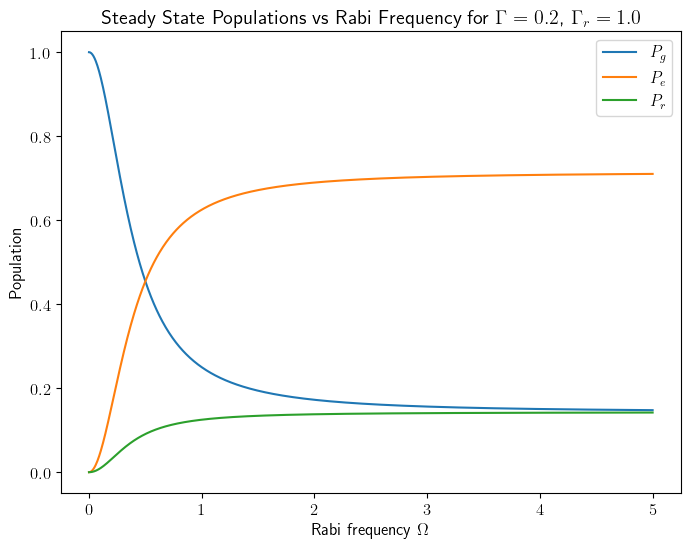

In [9]:
# plot the steady state populations
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(f'Steady State Populations vs Rabi Frequency for $\Gamma = {Gamma}$, $\Gamma_r = {Gamma_r}$')
ax.plot(Omega, pg_ss, label=r'$P_g$')
ax.plot(Omega, pe_ss, label=r'$P_e$')
ax.plot(Omega, pr_ss, label=r'$P_r$')
ax.set_xlabel(r'Rabi frequency $\Omega$')
ax.set_ylabel('Population')
ax.legend()

In [10]:
Gamma = 0.0005
Gamma_r = 1.0
Omega = np.linspace(0.0, 5.0, 1000)  # Rabi frequency range

jump_ops = [
    (s_ge, Gamma),  # spontaneous emission from excited state to ground state
    (s_er, Gamma_r)  # spontaneous emission from excited state to reservoir
]

# calculate the steady state for each Rabi frequency
steady_states = []
for omega in Omega:
    hamilton = H0(omega)
    L = build_Liouvillian_t_indep(hamilton, jump_ops=jump_ops)
    rho_ss = steady_state(L)
    steady_states.append(rho_ss)

print(jump_ops)

steady_states = np.array(steady_states)
# calculate populations in steady state
pg_ss = np.real(steady_states[:, 0])  # population of |g>
pe_ss = np.real(steady_states[:, 4])  # population of |e>
pr_ss = np.real(steady_states[:, 8])  # population of |r>

[(array([[0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j]]), 0.0005), (array([[0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j]]), 1.0)]


[0.999]


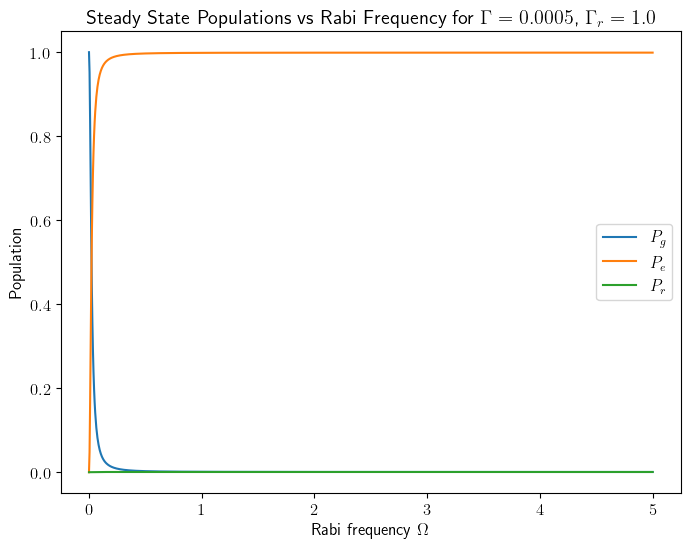

In [11]:
# plot the steady state populations
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(Omega, pg_ss, label=r'$P_g$')
ax.plot(Omega, pe_ss, label=r'$P_e$')
ax.plot(Omega, pr_ss, label=r'$P_r$')
ax.set_xlabel(r'Rabi frequency $\Omega$')
ax.set_ylabel('Population')
ax.set_title(f'Steady State Populations vs Rabi Frequency for $\Gamma = {Gamma}$, $\Gamma_r = {Gamma_r}$')
ax.legend()
print(pe_ss[-1])